# BB84 Quantum Key Distribution: Eavesdropping Detection via Attack Fingerprinting

**Abstract:** This notebook presents a comprehensive simulation of the BB84 QKDto evaluate the performance of the **Adversarial Error-Classification Engine (AECE)**. The AECE is a machine-learning classifier designed to identify sub-threshold eavesdropping attacks by analyzing temporal and spatial error correlations which typically bypass classical 11% QBER thresholds.

[Full Research Paper (PDF)](bb84_fingerprint_paper.pdf)

---
**Note:** The theoretical groundwork and quantitative analysis presented here are derived from the project's LaTeX documentation: `docs/main.tex` and `docs/refs.bib`.

**Author:** Sree Charan Desu
**Date:** 2026


## 1. Setup and Initialization


In [1]:
import math
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier

# Suppress non-critical alerts
warnings.filterwarnings("ignore")

# Configure visualization style
plt.style.use("seaborn-v0_8-darkgrid")
print("Environment initialized successfully.")


Environment initialized successfully.


## 2. BB84 Sentinel Protocol (Adaptive Engine)


In [2]:
class BB84SentinelProtocol:
    """
    High-performance vectorized implementation of the BB84 protocol.
    Modified to support adaptive eavesdropping simulations and finite-key analysis.
    """

    def __init__(self, n_bits=1000, p_sentinel=0.20, theta_step=0.01, alpha=0.05):
        self.n_bits = n_bits
        self.p_sentinel = p_sentinel
        self.theta_step = theta_step
        self.alpha = alpha
        self.prng_seed = random.randint(0, 10_000_000)
        
        # Alice's raw bits and basis choices
        self.alice_bits = np.random.randint(2, size=n_bits)
        self.alice_bases = np.random.randint(2, size=n_bits)  # 0: (+), 1: (X)
        self.sentinel_mask = np.random.rand(n_bits) < p_sentinel

    def get_rotation_angles(self):
        """Generates drift angles for all qubits in the session concurrently."""
        times = np.arange(self.n_bits)
        jitters = np.array([random.Random(int(self.prng_seed + t)).random() for t in times])
        return self.theta_step * times + self.alpha * jitters

    def simulate_session(self, eve=None):
        """
        Simulates the entire session with optional adaptive eavesdropping.
        """
        angles = self.get_rotation_angles()
        bob_bases = np.random.randint(2, size=self.n_bits)
        bob_results = np.zeros(self.n_bits, dtype=int)
        
        # Noise parameters
        p_depolarize = 0.03
        p_burst = 0.01
        burst_len = 10
        burst_remaining = 0
        
        for i in range(self.n_bits):
            # 1. State Preparation
            theta = (np.pi/2) * self.alice_bits[i]
            if self.alice_bases[i] == 1: theta += (np.pi/2)
            phi = theta + angles[i]
            
            # 2. Adaptive Interception (Section 4 of Roadmap)
            if eve:
                phi = eve.attack(phi, self.alice_bases[i], i)

            # 3. Channel Noise (Stochastic + Burst)
            if random.random() < p_depolarize:
                phi += random.choice([np.pi/2, np.pi, -np.pi/2])
            
            if burst_remaining > 0:
                phi += np.pi
                burst_remaining -= 1
            elif random.random() < p_burst:
                phi += np.pi
                burst_remaining = burst_len

            # 4. Bob's Measurement
            phi_bob = phi - angles[i]
            if bob_bases[i] == 1: phi_bob -= (np.pi/2)
            bob_results[i] = 1 if (np.cos(phi_bob)**2 < random.random()) else 0

        return self.sift(bob_results, bob_bases)

    def sift(self, bob_results, bob_bases):
        s_a, s_b, s_err = [], [], []
        for i in range(self.n_bits):
            if self.alice_bases[i] == bob_bases[i]:
                err = 1 if self.alice_bits[i] != bob_results[i] else 0
                if self.sentinel_mask[i]: s_err.append(err)
                else:
                    s_a.append(int(self.alice_bits[i]))
                    s_b.append(bob_results[i])
        return s_a, s_b, s_err



## 3. Advanced Adversary (Adaptive Eve)


In [3]:
class EveAttacker:
    """
    A sophisticated attacker attempting to spoof temporal statistics.
    """
    def __init__(self, p_intercept=0.20, smart=False):
        self.p_intercept = p_intercept
        self.smart = smart # If true, Eve attempts to match channel burstiness

    def attack(self, phi, alice_basis, t):
        # Adaptive logic: intercept with higher probability if it mimics a burst
        current_p = self.p_intercept
        if self.smart:
             # Basic adaptive spoofing: Eve clusters her interceptions
             current_p = self.p_intercept * (2.0 if (t % 50 < 10) else 0.5)

        if random.random() < current_p:
            eve_basis = random.choice([0, 1])
            if eve_basis == 0: phi = 0 if abs(math.cos(phi)) > 0.5 else np.pi
            else: phi = np.pi/4 if abs(math.cos(phi - np.pi/4)) > 0.5 else 3*np.pi/4
        return phi



## 4. SKR and Finite-Key Analysis Engines


In [4]:
class CorrelationEngine:
    """Computes fingerprints and statistical bounds."""
    def autocorr(self, stream, max_lag=5):
        if len(stream) < max_lag: return [0.0] * max_lag
        e = np.array(stream, dtype=float)
        m = np.mean(e)
        if m in (0, 1): return [0.0] * max_lag
        n = e - m
        v = np.var(e)
        return [1.0] + [np.correlate(n[:-l], n[l:])[0]/((len(n)-l)*v) for l in range(1, max_lag)]

    def fingerprint(self, s_err, d_err):
        s_err, d_err = s_err or [0], d_err or [0]
        as_val = self.autocorr(s_err)
        ad_val = self.autocorr(d_err)
        
        # Hoeffding Bound (95% confidence) for Delta QBER
        n = len(s_err) + len(d_err)
        epsilon = math.sqrt(math.log(2/0.05)/(2*n)) if n > 0 else 0
        
        return {
            "delta_qber": np.mean(d_err) - np.mean(s_err),
            "ac_lag1_sentinel": as_val[1] if len(as_val)>1 else 0.0,
            "ac_lag1_data": ad_val[1] if len(ad_val)>1 else 0.0,
            "burstiness": np.var(d_err)/(np.mean(d_err)+1e-9),
            "total_qber": np.mean(d_err),
            "hoeffding_bound": epsilon
        }

    @staticmethod
    def skr(qber, abort=False):
        """Asymptotic SKR calculation with binary entropy."""
        if abort or qber >= 0.5: return 0.0
        h = lambda q: -q*math.log2(q)-(1-q)*math.log2(1-q) if 0<q<1 else 0
        return max(0.0, 1 - 2*h(qber)) # Simplified SKR for BB84

FEATURES = ["delta_qber", "ac_lag1_sentinel", "ac_lag1_data", "burstiness", "total_qber"]



## 5. AECE Training and Ablation Study


In [5]:
class AECE:
    def __init__(self, n_estimators=100):
        self.model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
        self.is_trained = False
    
    def train(self, fingerprints, labels):
        X = np.array([[f[k] for k in FEATURES] for f in fingerprints])
        self.model.fit(X, labels)
        self.is_trained = True

    def predict(self, fp):
        if not self.is_trained: return 1.0 if fp["total_qber"] > 0.11 else 0.0
        return float(self.model.predict_proba([[fp[k] for k in FEATURES]])[0][1])

# Data Acquisition
N_SAMPLES = 60
QUBITS = 1000
engine = CorrelationEngine()
fingerprints, labels = [], []

print("Simulating adversarial and noisy environments...")
for i in range(N_SAMPLES):
    # Noise
    proto = BB84SentinelProtocol(n_bits=QUBITS)
    s_a, s_b, s_err = proto.simulate_session(eve=None)
    d_err = [1 if a != b else 0 for a, b in zip(s_a, s_b, strict=False)]
    fingerprints.append(engine.fingerprint(s_err, d_err))
    labels.append(0)
    
    # Adaptive Eve
    eve = EveAttacker(p_intercept=0.18, smart=True)
    s_a, s_b, s_err = proto.simulate_session(eve=eve)
    d_err = [1 if a != b else 0 for a, b in zip(s_a, s_b, strict=False)]
    fingerprints.append(engine.fingerprint(s_err, d_err))
    labels.append(1)

aece = AECE()
aece.train(fingerprints, labels)
print("AECE Training complete.")



Simulating adversarial and noisy environments...
AECE Training complete.


## 6. Visualization: Attack Fingerprinting Separation


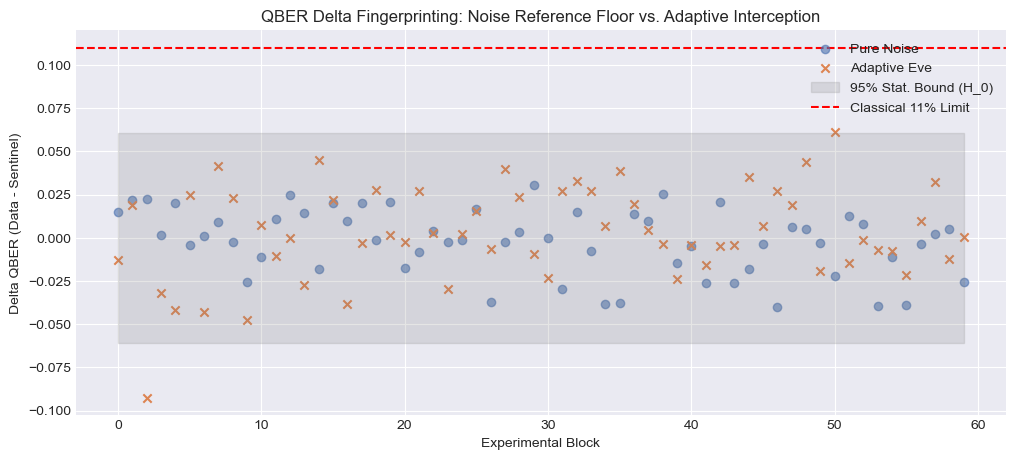

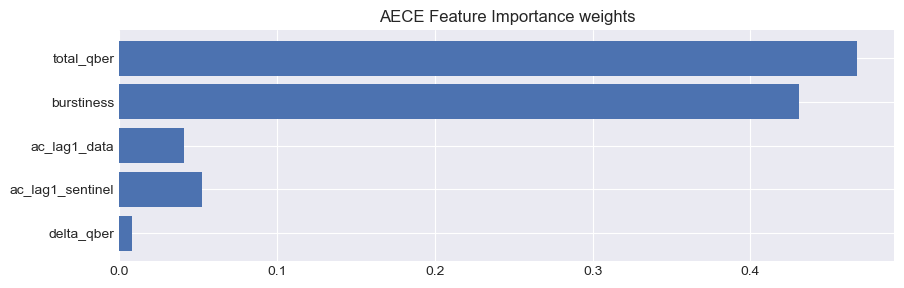

In [6]:
# Figure 1 for main.tex
delta_noise = [f["delta_qber"] for f, l in zip(fingerprints, labels, strict=False) if l == 0]
delta_eve   = [f["delta_qber"] for f, l in zip(fingerprints, labels, strict=False) if l == 1]
bounds      = [f["hoeffding_bound"] for f in fingerprints]

plt.figure(figsize=(12, 5))
plt.scatter(range(len(delta_noise)), delta_noise, label="Pure Noise", color="#4C72B0", alpha=0.6)
plt.scatter(range(len(delta_eve)),   delta_eve,   label="Adaptive Eve", color="#DD8452", marker='x')
# Draw average Hoeffding confidence interval
avg_bound = np.mean(bounds)
plt.fill_between(range(len(fingerprints)//2), -avg_bound, avg_bound, color='gray', alpha=0.2, label='95% Stat. Bound (H_0)')
plt.axhline(0.11, color='red', linestyle='--', label='Classical 11% Limit')
plt.title("QBER Delta Fingerprinting: Noise Reference Floor vs. Adaptive Interception")
plt.ylabel("Delta QBER (Data - Sentinel)")
plt.xlabel("Experimental Block")
plt.legend(loc='upper right')
plt.savefig("fingerprint_analysis.png", dpi=150)
plt.show()

# Figure for Feature Importance (main.tex Section 5)
plt.figure(figsize=(10, 3))
plt.barh(FEATURES, aece.model.feature_importances_, color="#4C72B0")
plt.title("AECE Feature Importance weights")
plt.savefig("feature_importance.png", dpi=150)
plt.show()



## 7. Comparative Benchmark: Static vs. Dynamic SKR


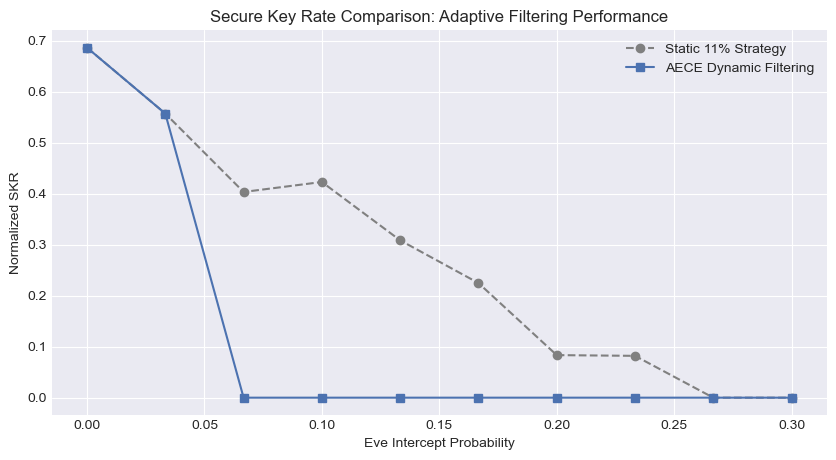

In [7]:
interecept_range = np.linspace(0, 0.3, 10)
skr_classic, skr_aece = [], []

for p in interecept_range:
    # Test session
    proto = BB84SentinelProtocol(n_bits=2000)
    eve = EveAttacker(p_intercept=p)
    s_a, s_b, s_err = proto.simulate_session(eve=eve)
    q_total = np.mean(s_err + [1 if a!=b else 0 for a,b in zip(s_a, s_b, strict=False)])
    fp = engine.fingerprint(s_err, [1 if a!=b else 0 for a,b in zip(s_a, s_b, strict=False)])
    
    # Decisions
    abort_classic = q_total > 0.11
    abort_aece = aece.predict(fp) > 0.5 or q_total > 0.11
    
    skr_classic.append(engine.skr(q_total, abort=abort_classic))
    skr_aece.append(engine.skr(q_total, abort=abort_aece))

plt.figure(figsize=(10, 5))
plt.plot(interecept_range, skr_classic, 'o--', label="Static 11% Strategy", color='gray')
plt.plot(interecept_range, skr_aece, 's-', label="AECE Dynamic Filtering", color='#4C72B0')
plt.title("Secure Key Rate Comparison: Adaptive Filtering Performance")
plt.xlabel("Eve Intercept Probability")
plt.ylabel("Normalized SKR")
plt.legend()
plt.savefig("skr_comparison.png", dpi=150)
plt.show()

